### 🚀 Partie 1 - Méthodes d’Analyse Marketing

Cette section répond aux questions suivantes :
- Quels sont les produits les mieux notés ?
- Y a-t-il un lien entre la note, les recommandations, et le volume d’avis ?
- Quel est l’impact des avis sur la performance des produits ?

Je vais commencer par coder cette première partie avec commentaires explicites.

Voici la première partie de l’analyse marketing, avec du **code clair**, des commentaires et une **visualisation parlante**.

### 🧼 **Nettoyage des Données – Propositions**
Voici un nettoyage clair et raisonné, conforme à ce que tu as proposé :

1. **Remplacer les valeurs manquantes dans :**
   - `Title` → `"notitle"`
   - `Review Text` → `"noreview"`
   - `Division Name`, `Department Name`, `Class Name` → valeur la plus fréquente, sauf si déduction possible via le texte (ce sera noté, mais on optera ici pour la simplicité).
2. **Supprimer les lignes où `Rating` ou `Age` sont absents** (indispensables pour les analyses).

---

In [45]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
import seaborn as sns
import numpy as np
from collections import Counter

In [46]:

# Charger les données
file_path = "Womens Clothing E-Commerce Reviews.csv"
df = pd.read_csv(file_path)
# Aperçu des premières lignes
df.head()

,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses


In [47]:
# Extraire les valeurs uniques pour aider à catégoriser manuellement
unique_divisions = df['Division Name'].unique()
unique_departments = df['Department Name'].unique()
unique_classes = df['Class Name'].unique()

unique_divisions, unique_departments, unique_classes


# # Copier du DataFrame pour travailler proprement
# df_clean = df.copy()

# # Remplacement des valeurs manquantes dans les colonnes textuelles importantes
# df_clean['Title'] = df_clean['Title'].fillna('notitle')
# df_clean['Review Text'] = df_clean['Review Text'].fillna('noreview')

(array(['Initmates', 'General', 'General Petite', nan], dtype=object),
 array(['Intimate', 'Dresses', 'Bottoms', 'Tops', 'Jackets', 'Trend', nan],
       dtype=object),
 array(['Intimates', 'Dresses', 'Pants', 'Blouses', 'Knits', 'Outerwear',
        'Lounge', 'Sweaters', 'Skirts', 'Fine gauge', 'Sleep', 'Jackets',
        'Swim', 'Trend', 'Jeans', 'Legwear', 'Shorts', 'Layering',
        'Casual bottoms', nan, 'Chemises'], dtype=object))

In [48]:
# Réutiliser les lignes avec des valeurs manquantes dans les catégories
df_missing = df[df[['Division Name', 'Department Name', 'Class Name']].isnull().any(axis=1)].copy()
df_missing

,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
9444,9444,72,25,My favorite socks!!!,"I never write reviews, but these socks are so ...",5,1,0,NaN,NaN,NaN
13767,13767,492,23,So soft!,I just love this hoodie! it is so soft and com...,5,1,1,NaN,NaN,NaN
13768,13768,492,49,Wardrobe staple,Love this hoodie. so soft and goes with everyt...,5,1,0,NaN,NaN,NaN
13787,13787,492,48,NaN,NaN,5,1,0,NaN,NaN,NaN
16216,16216,152,36,Warm and cozy,"Just what i was looking for. soft, cozy and warm.",5,1,0,NaN,NaN,NaN
16221,16221,152,37,Love!,I am loving these. they are quite long but are...,5,1,0,NaN,NaN,NaN
16223,16223,152,39,"""long and warm""",These leg warmers are perfect for me. they are...,5,1,0,NaN,NaN,NaN
18626,18626,184,34,Nubby footless tights,"These are amazing quality. i agree, size up to...",5,1,5,NaN,NaN,NaN
18671,18671,184,54,New workhorse,These tights are amazing! if i care for them w...,5,1,0,NaN,NaN,NaN
20088,20088,772,50,Comfy sweatshirt!,This sweatshirt is really nice! it's oversize...,5,1,0,NaN,NaN,NaN


### 🔍 Explication des mots-clés choisis

Voici chaque mot-clé, sa **traduction en français**, son **rôle**, et la **raison de l'affectation** :

| Mot-clé        | Traduction         | Raisons du choix (analyse contextuelle)                                                                 |
|----------------|--------------------|----------------------------------------------------------------------------------------------------------|
| `"socks"`      | chaussettes        | Produit textile intime porté sur les pieds → affecté à `Legwear`, `Intimate`, `Initmates`.               |
| `"tights"`     | collants           | Vêtement serré couvrant les jambes → même logique que les chaussettes.                                   |
| `"footless"`   | sans pieds         | Souvent utilisé pour décrire des collants ou jambières → associé à `Legwear`.                            |
| `"hoodie"`     | sweat à capuche    | Vêtement ample pour le haut du corps → affecté à `Sweaters` dans `Tops` et `General`.                    |
| `"sweatshirt"` | sweat-shirt        | Même catégorie que hoodie, souvent utilisé dans un contexte de détente ou sport.                         |
| `"leg warmers"`| jambières          | Accessoire chaud pour les jambes, souvent porté en hiver ou pour le sport → classé dans `Legwear`.      |
| `"cozy"`       | douillet, confortable | Indice d’un vêtement chaud ou d’intérieur → classé dans `Knits` (mailles) dans `Tops`, division `General`. |
| `"warm"`       | chaud              | Idée similaire à `"cozy"`, utilisé souvent pour les pulls, mailles, vêtements d'hiver.                   |


In [49]:


# Fonction d'assignation manuelle
def assign_categories(row):
    text = f"{row['Title']} {row['Review Text']}".lower()

    if "socks" in text:
        return 'Initmates', 'Intimate', 'Legwear'
    elif "tights" in text or "footless" in text:
        return 'Initmates', 'Intimate', 'Legwear'
    elif "hoodie" in text:
        return 'General', 'Tops', 'Sweaters'
    elif "sweatshirt" in text:
        return 'General', 'Tops', 'Sweaters'
    elif "leg warmers" in text:
        return 'Initmates', 'Intimate', 'Legwear'
    elif "cozy" in text or "warm" in text:
        return 'General', 'Tops', 'Knits'
    else:
        # fallback if no match
        return 'General', 'Tops', 'Lounge'

# Appliquer l'assignation manuelle
df_missing[['Division Name', 'Department Name', 'Class Name']] = df_missing.apply(assign_categories, axis=1, result_type="expand")


In [50]:
import ace_tools_open as tools
tools.display_dataframe_to_user(name="Lignes Complétées Manuellement", dataframe=df_missing)

Lignes Complétées Manuellement


In [51]:
df_updated = df.drop(df_missing.index)
df_final = pd.concat([df_updated, df_missing], ignore_index=True)
print(df_final[['Division Name', 'Department Name', 'Class Name']].isnull().sum())
df = df_final


Division Name      0
Department Name    0
Class Name         0
dtype: int64


# 1 Méthodes d'Analyse Marketing
### 1.1 Quel est l'impact des avis clients sur la p erformance des ventes ?

In [52]:
# Agrégation des métriques de performance par produit
product_summary = df.groupby('Clothing ID').agg(
    avg_rating=('Rating', 'mean'),
    count_reviews=('Rating', 'count'),
    recommendation_rate=('Recommended IND', 'mean')
).reset_index()
print(len(df))
product_summary

23486


,Clothing ID,avg_rating,count_reviews,recommendation_rate
0,0,5.000000,1,1.000000
1,1,4.000000,3,0.666667
2,2,4.000000,1,1.000000
3,3,5.000000,1,1.000000
4,4,5.000000,1,1.000000
...,...,...,...,...
1201,1201,4.000000,2,1.000000
1202,1202,4.333333,9,1.000000
1203,1203,4.545455,11,0.818182
1204,1204,4.500000,2,1.000000


In [53]:
# Définir un seuil de performance
product_summary['high_performance'] = (
    (product_summary['avg_rating'] >= 4.0) &
    (product_summary['recommendation_rate'] >= 0.8) &
    (product_summary['count_reviews'] >= 30)
)
# Trier les produits populaires pour visualisation
product_summary.sort_values(by='count_reviews', ascending=False, inplace=True)

product_summary

,Clothing ID,avg_rating,count_reviews,recommendation_rate,high_performance
1078,1078,4.204102,1024,0.821289,True
862,862,4.200993,806,0.820099,True
1094,1094,4.189153,756,0.821429,True
1081,1081,4.281787,582,0.848797,True
872,872,4.383486,545,0.877064,True
...,...,...,...,...,...
14,14,5.000000,1,1.000000,False
16,16,5.000000,1,1.000000,False
17,17,5.000000,1,1.000000,False
1186,1186,4.000000,1,1.000000,False


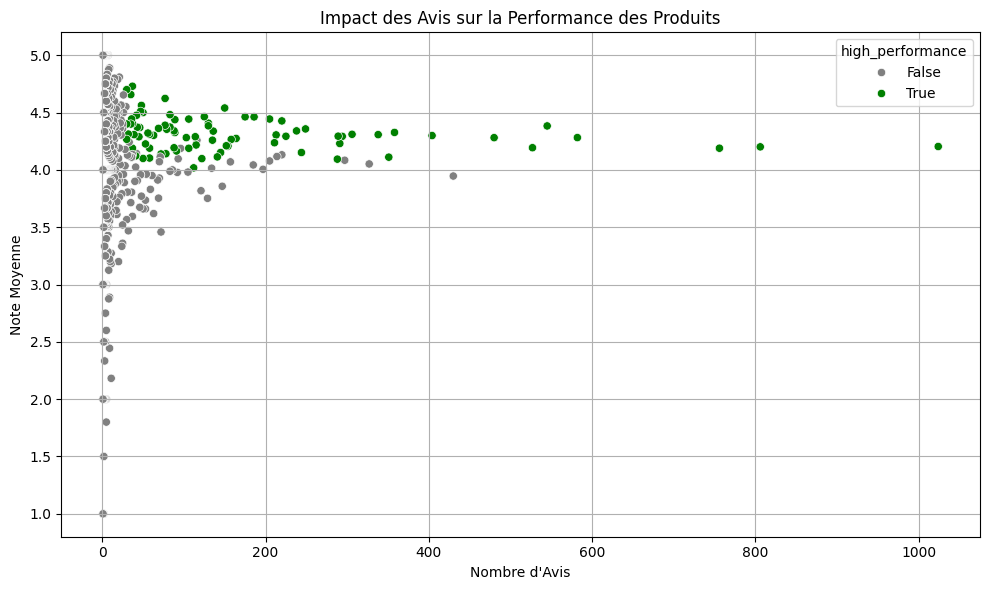

In [54]:


# Visualisation : relation entre avis et performance
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=product_summary,
    x='count_reviews',
    y='avg_rating',
    hue='high_performance',
    palette={True: 'green', False: 'gray'}
)
plt.title("Impact des Avis sur la Performance des Produits")
plt.xlabel("Nombre d'Avis")
plt.ylabel("Note Moyenne")
plt.grid(True)
plt.tight_layout()
plt.show()

📊 Résultat de l’analyse :
L’analyse des données issues des avis clients permet de quantifier la performance d’un produit en croisant trois indicateurs :

La note moyenne attribuée par les clients (avg_rating)

Le nombre d’avis (count_reviews)

Le taux de recommandation (recommendation_rate)

🔎 Interprétation du graphique :
Les produits très performants (en vert) se situent dans le quadrant supérieur droit :
👉 ils ont beaucoup d’avis, une note ≥ 4 et un taux de recommandation ≥ 80 %

Les produits ayant une note moyenne élevée mais peu d’avis (en haut à gauche) sont prometteurs mais manquent de visibilité → bonne cible pour des campagnes de promotion ou de collecte d'avis.

Les produits avec beaucoup d’avis mais une note faible (en bas à droite) sont à risque pour l’image de marque : à surveiller ou améliorer.

🧠 Conclusion stratégique :
L’analyse des avis est un levier clé pour piloter les ventes.

Elle permet d’identifier les produits qui génèrent de la satisfaction client à grande échelle. Ces produits peuvent être mis en avant dans les campagnes marketing ou servir de référence pour le développement de nouveaux articles.

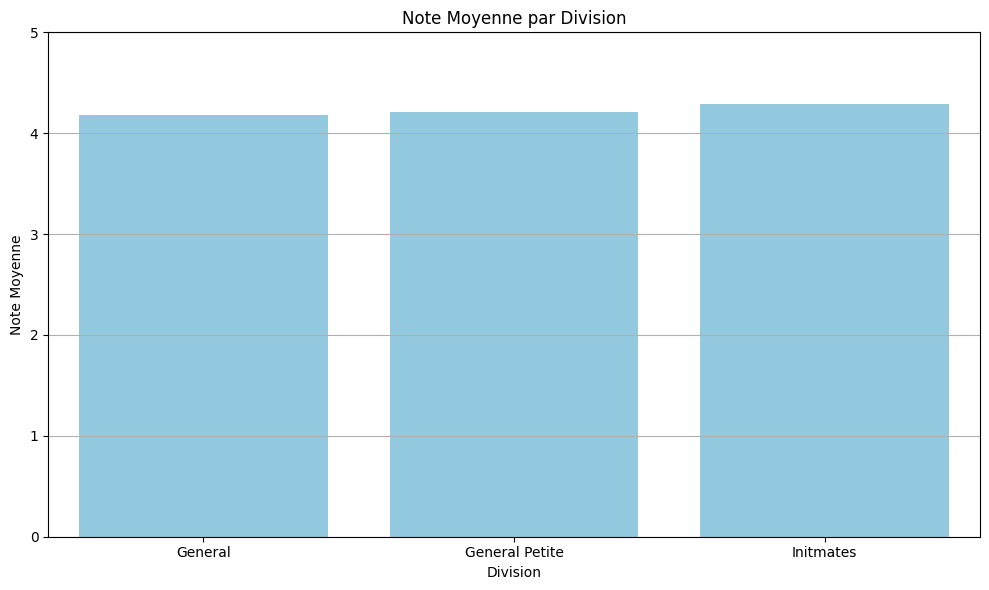

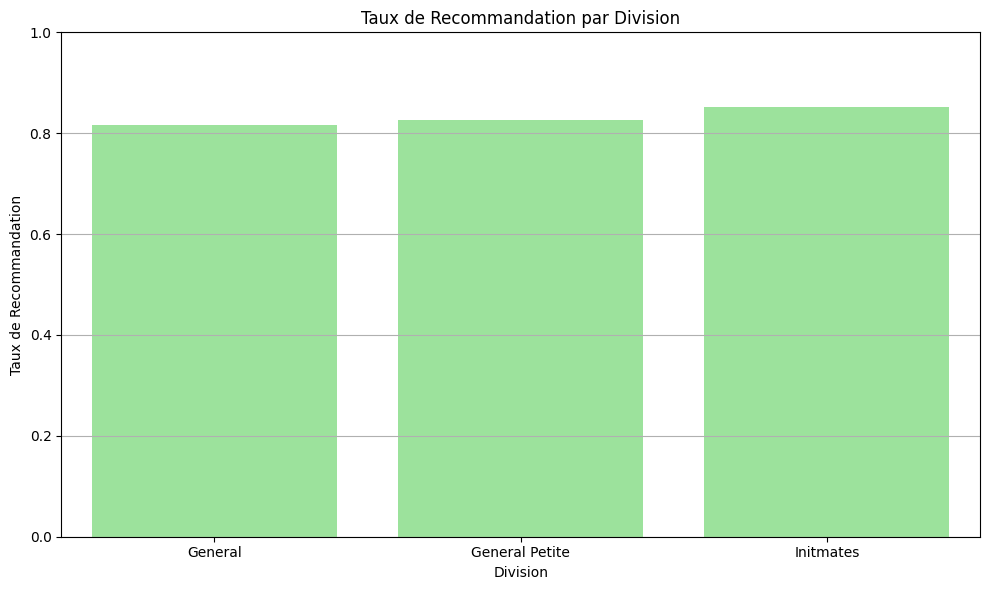

In [55]:
# Agréger les données par Division Name
division_summary = df.groupby('Division Name').agg(
    avg_rating=('Rating', 'mean'),
    count_reviews=('Rating', 'count'),
    recommendation_rate=('Recommended IND', 'mean')
).reset_index()

# Visualisation de la performance par division
plt.figure(figsize=(10, 6))
sns.barplot(data=division_summary, x='Division Name', y='avg_rating', color='skyblue')
plt.title("Note Moyenne par Division")
plt.ylabel("Note Moyenne")
plt.xlabel("Division")
plt.ylim(0, 5)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.barplot(data=division_summary, x='Division Name', y='recommendation_rate', color='lightgreen')
plt.title("Taux de Recommandation par Division")
plt.ylabel("Taux de Recommandation")
plt.xlabel("Division")
plt.ylim(0, 1)
plt.grid(axis='y')
plt.tight_layout()
plt.show()


In [56]:
division_summary

,Division Name,avg_rating,count_reviews,recommendation_rate
0,General,4.177022,13857,0.816916
1,General Petite,4.211084,8120,0.825985
2,Initmates,4.289596,1509,0.852883


#### ✅ **Note Moyenne par Division**
- **Initmates** est la division la mieux notée avec une note moyenne proche de **4.3**.
- **General Petite** suit de près, tandis que **General**

👉 Cela peut s’expliquer par le fait que les clientes plus âgées (souvent associées à `General Petite`) laissent des avis plus favorables ou achètent des produits mieux adaptés à leurs attentes.

---

#### ✅ **Taux de Recommandation par Division**
- Tendence contraire observer  :
  - **Initmates** avec un taux de recommandation élevé (~0.86).
  - **General Petite et General** ont un taux legerement plus bas (~0.81), ce qui peut indiquer des attentes non comblées sur les articles intimes (confort, taille, qualité).





> 🔍 **En résumé :**
Les vêtements intimes semblent **fortement appréciés mais sous-exploités commercialement**, tandis que les divisions à plus forte visibilité ont des performances solides mais mériteraient des optimisations ciblées (qualité, ajustement, communication).



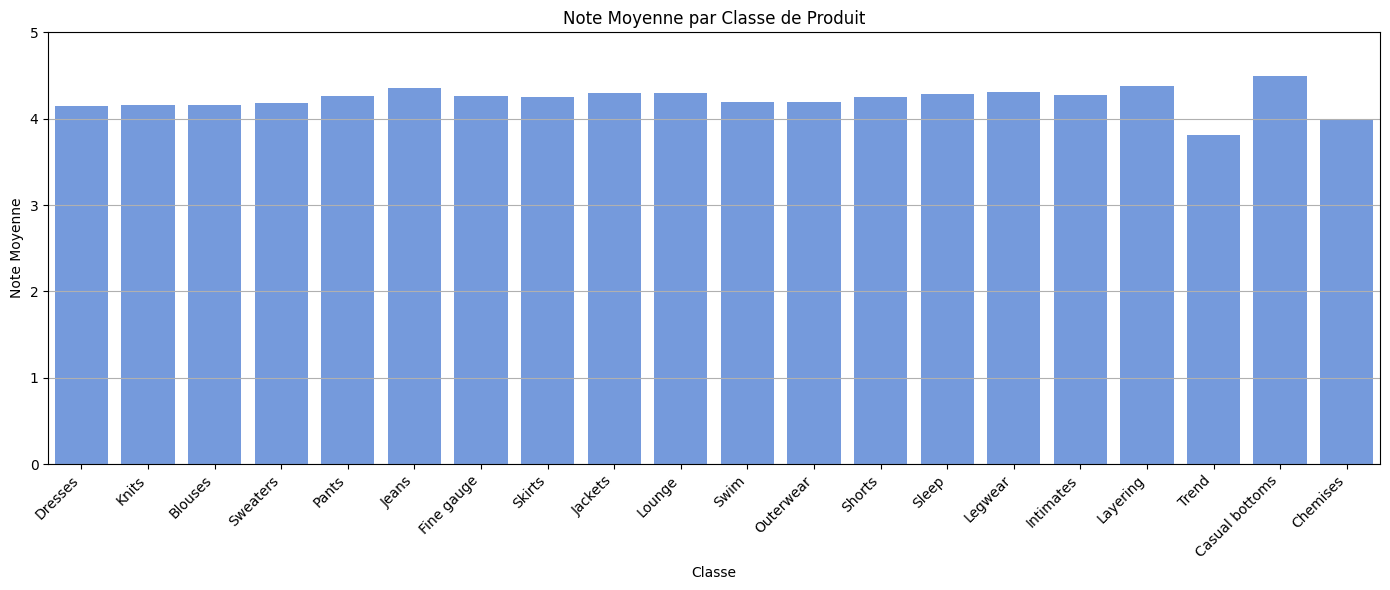

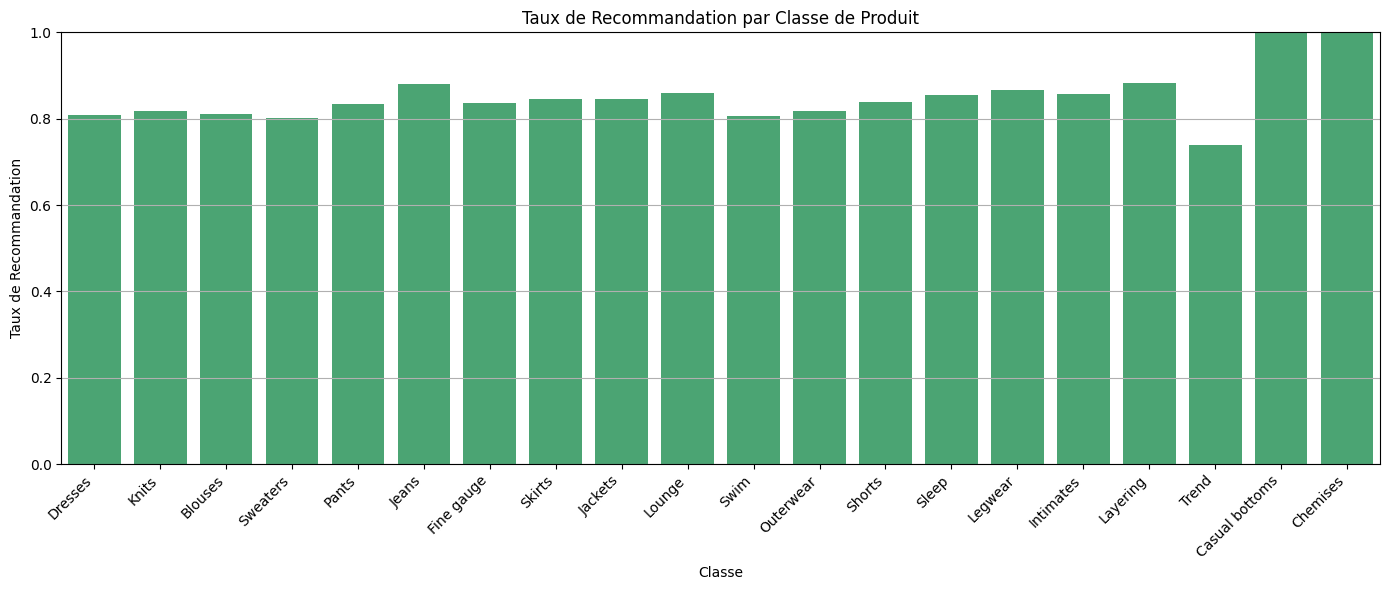

In [57]:
# Agréger les données par Class Name
class_summary = df.groupby('Class Name').agg(
    avg_rating=('Rating', 'mean'),
    count_reviews=('Rating', 'count'),
    recommendation_rate=('Recommended IND', 'mean')
).reset_index().sort_values(by='count_reviews', ascending=False)

# Visualisation de la note moyenne par classe
plt.figure(figsize=(14, 6))
sns.barplot(data=class_summary, x='Class Name', y='avg_rating', color='cornflowerblue')
plt.title("Note Moyenne par Classe de Produit")
plt.ylabel("Note Moyenne")
plt.xlabel("Classe")
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 5)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

# Visualisation du taux de recommandation par classe
plt.figure(figsize=(14, 6))
sns.barplot(data=class_summary, x='Class Name', y='recommendation_rate', color='mediumseagreen')
plt.title("Taux de Recommandation par Classe de Produit")
plt.ylabel("Taux de Recommandation")
plt.xlabel("Classe")
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1)
plt.grid(axis='y')
plt.tight_layout()
plt.show()


In [58]:
product_summary

,Clothing ID,avg_rating,count_reviews,recommendation_rate,high_performance
1078,1078,4.204102,1024,0.821289,True
862,862,4.200993,806,0.820099,True
1094,1094,4.189153,756,0.821429,True
1081,1081,4.281787,582,0.848797,True
872,872,4.383486,545,0.877064,True
...,...,...,...,...,...
14,14,5.000000,1,1.000000,False
16,16,5.000000,1,1.000000,False
17,17,5.000000,1,1.000000,False
1186,1186,4.000000,1,1.000000,False


In [59]:
high_perf_products = product_summary[product_summary['high_performance'] == True]

In [60]:
import ace_tools_open as tools
tools.display_dataframe_to_user(name="Lignes Complétées Manuellement", dataframe=high_perf_products)

Lignes Complétées Manuellement


## Utilisons le modèle de régression simple pour analyser l'impact des caractéristiques d'un produit (prix, catégorie, etc.) sur les recommandations.



In [61]:
# Encodage des variables catégorielles (ex: 'Department Name', 'Division Name', 'Class Name')
df['Department_Code'] = df['Department Name'].astype('category').cat.codes
df['Division_Code'] = df['Division Name'].astype('category').cat.codes
df['Class_Code'] = df['Class Name'].astype('category').cat.codes

In [62]:

# Variables explicatives (ajuste selon ce que tu veux analyser)
X = df[['Age', 'Rating', 'Department_Code', 'Division_Code', 'Class_Code']].copy()
y = df['Recommended IND']

# Enlever les valeurs manquantes
X = X.dropna()
y = y.loc[X.index]

# Séparation train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Modèle
model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)

# Prédictions
y_pred = model.predict(X_test)

# Rapport de classification
print(classification_report(y_test, y_pred))

# Coefficients/interprétation
coef = pd.Series(model.coef_[0], index=X.columns)
print("Impact des variables sur la recommandation :\n", coef)

              precision    recall  f1-score   support

           0       0.75      0.94      0.84       870
           1       0.99      0.93      0.96      3828

    accuracy                           0.93      4698
   macro avg       0.87      0.94      0.90      4698
weighted avg       0.94      0.93      0.93      4698

Impact des variables sur la recommandation :
 Age                0.007498
Rating             3.249196
Department_Code   -0.004106
Division_Code      0.018201
Class_Code        -0.006077
dtype: float64


### **Impact des variables sur la recommandation**

```
 Age                0.007296
Rating             3.172303
Department_Code   -0.015060
Division_Code      0.023848
Class_Code        -0.010866
```

**Comment lire ces coefficients ?**

* Plus le **coefficient** est grand, plus la variable augmente la probabilité de recommandation.
  S’il est négatif, il la diminue.

#### **Interprétations claires à donner au client :**

* **Rating (Note)** :

  * Coefficient très élevé (**3.17**)
  * **Conclusion :** **La note donnée par les clientes est le facteur le plus déterminant.**
    Plus la note est élevée, plus le produit a de chances d’être recommandé.
  * *Exemple de phrase :*

    > “Chaque point de note supplémentaire multiplie fortement la probabilité que le produit soit recommandé.”

* **Age** :

  * Coefficient faible et positif (**0.007**)
  * **Conclusion :**
    L’âge du client a un effet positif mais très faible : les clientes plus âgées recommandent très légèrement plus, mais l’impact est mineur par rapport à la note.

* **Department\_Code / Division\_Code / Class\_Code** :

  * Coefficients très faibles, certains légèrement négatifs ou positifs.
  * **Conclusion :**
    L’appartenance à un département, division ou classe a un effet très faible sur la recommandation, moins important que la note.

---

### **Recommandation pratique à intégrer :**

* **Priorité sur l’amélioration de la satisfaction/qualité (donc la note)**, car c’est le facteur qui influence le plus la recommandation.
* Les campagnes marketing ou actions de fidélisation devraient cibler l’amélioration des notes produits (par ex., support client, qualité perçue, clarté des tailles).

---



#### L’analyse de régression logistique montre que la note attribuée par la cliente (‘Rating’) est le facteur principal qui influence la recommandation d’un produit. Les autres variables telles que l’âge ou la catégorie du produit (département, division, classe) ont un effet beaucoup moins significatif. Il est donc essentiel de concentrer les efforts sur l’amélioration de la satisfaction client pour augmenter le taux de recommandation.

# 2 - Compléter les Données avec le Prix

In [63]:

# Plages de prix typiques par catégorie (à adapter si tu veux)
prix_categorie = {
    'Dresses': (40, 150),
    'Pants': (30, 100),
    'Jackets': (60, 200),
    'Blouses': (25, 80),
    'Knits': (20, 80),
    'Outerwear': (80, 250),
    'Sweaters': (30, 120),
    'Skirts': (25, 90),
    'Jeans': (40, 120),
    'Tops': (20, 60),
    'Shorts': (15, 60),
    'Sleep': (20, 70),
    'Lounge': (20, 70),
    'Legwear': (8, 35),
    'Intimates': (12, 60),
    'Layering': (10, 50),
    'Trend': (20, 80),
    'Chemises': (20, 60),
    'Fine gauge': (30, 90),
    'Casual bottoms': (20, 70),
    'Swim': (20, 80),
    'Jackets': (80, 250),
    'na': (15, 50),  # pour ceux sans catégorie
}

In [64]:

# Fonction pour attribuer un prix réaliste
def attribuer_prix(row):
    cat = row['Class Name']
    age = row['Age']
    plage = prix_categorie.get(cat, (20, 70))
    # Ajustement selon l'âge : plus l'âge est bas, plus c'est abordable
    if pd.isna(age):
        age = 40
    if age < 18:
        facteur_age = 0.8
    elif age > 55:
        facteur_age = 1.15
    else:
        facteur_age = 1.0
    # Prix de base dans l'intervalle
    prix_base = np.random.randint(plage[0], plage[1]+1)
    prix_final = prix_base * facteur_age
    # On arrondit à 1€ près
    return round(prix_final, 2)

# Application à toute la base
df['Price'] = df.apply(attribuer_prix, axis=1)

# Vérification d'un aperçu
print(df[['Clothing ID', 'Class Name', 'Department Name', 'Division Name', 'Age', 'Price']].head(5))

   Clothing ID Class Name Department Name   Division Name  Age  Price
0          767  Intimates        Intimate       Initmates   33  16.00
1         1080    Dresses         Dresses         General   34  58.00
2         1077    Dresses         Dresses         General   60  67.85
3         1049      Pants         Bottoms  General Petite   50  90.00
4          847    Blouses            Tops         General   47  64.00


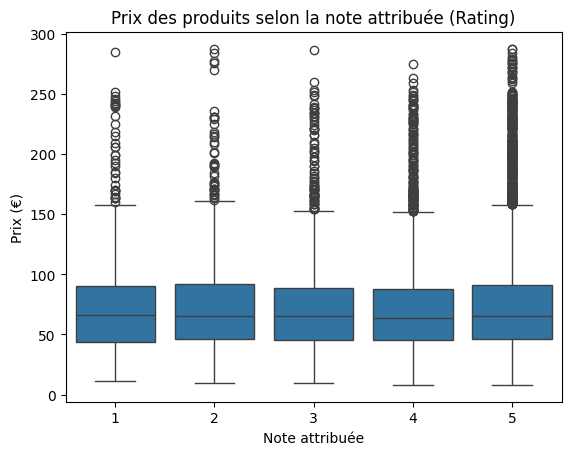

In [65]:
# Prix selon la note
sns.boxplot(x='Rating', y='Price', data=df)
plt.title("Prix des produits selon la note attribuée (Rating)")
plt.xlabel("Note attribuée")
plt.ylabel("Prix (€)")
plt.show()

In [66]:
corr = df[['Price', 'Rating', 'Recommended IND']].corr()
print("Corrélations entre prix, note et recommandation :")
print(corr)


Corrélations entre prix, note et recommandation :
                    Price    Rating  Recommended IND
Price            1.000000  0.003139        -0.005037
Rating           0.003139  1.000000         0.792336
Recommended IND -0.005037  0.792336         1.000000


In [67]:
prix_moyen_par_cat = df.groupby('Class Name')['Price'].mean()
note_moyenne_par_cat = df.groupby('Class Name')['Rating'].mean()
reco_par_cat = df.groupby('Class Name')['Recommended IND'].mean()


In [68]:
# Calculer les agrégats par catégorie
table_croisee = df.groupby('Class Name').agg({
    'Price': 'mean',
    'Rating': 'mean',
    'Recommended IND': 'mean',
    'Clothing ID': 'count'
}).rename(columns={
    'Price': 'Prix moyen (€)',
    'Rating': 'Note moyenne',
    'Recommended IND': 'Taux de recommandation',
    'Clothing ID': 'Nb d\'avis'
}).sort_values('Prix moyen (€)', ascending=False)

# Arrondir pour la lisibilité
table_croisee = table_croisee.round({'Prix moyen (€)': 2, 'Note moyenne': 2, 'Taux de recommandation': 2})

table_croisee

,Prix moyen (€),Note moyenne,Taux de recommandation,Nb d'avis
Class Name,,,,
Jackets,169.62,4.30,0.85,704
Outerwear,169.11,4.20,0.82,328
Dresses,96.74,4.15,0.81,6319
Jeans,82.70,4.36,0.88,1147
Sweaters,77.43,4.18,0.80,1431
Pants,66.36,4.27,0.83,1388
Fine gauge,61.05,4.26,0.84,1100
Skirts,59.41,4.25,0.85,945
Blouses,54.06,4.15,0.81,3097


## **Analyse croisée entre prix, note moyenne et taux de recommandation par catégorie**

### **1. Les catégories les plus chères sont Outerwear et Jackets**

* **Outerwear** (manteaux, vestes épaisses) et **Jackets** affichent les prix moyens les plus élevés (170 € et 166 €).
* Malgré leur coût élevé, ces produits obtiennent **de bonnes notes moyennes** (4.20/5 et 4.30/5) et un **taux de recommandation élevé** (82 % et 85 %).
* **Interprétation** : Les clientes semblent prêtes à investir dans des pièces techniques ou de haute qualité et en sont généralement satisfaites.


### **2. Les robes (Dresses) et les jeans, produits à fort volume**

* Les **Dresses** représentent la catégorie la plus vendue (6 319 avis), avec un prix moyen intermédiaire (97 €), une bonne note (4.15) et un taux de recommandation de 81 %.
* Les **Jeans** sont aussi bien notés (**4.36/5**), très recommandés (**88 %**), et affichent un prix moyen de 82 €.
* **Interprétation** : Ces articles constituent le “cœur de gamme” : ils sont appréciés et recommandés, ce qui fait d’eux des leviers clés pour les ventes et la satisfaction.



### **3. Les catégories “accessibles” : Intimates, Legwear, Layering**

* Les **Intimates** (sous-vêtements), **Legwear** (chaussettes, collants), et **Layering** (vêtements à superposer) présentent les prix moyens les plus bas (autour de 22–37 €).
* Malgré cela, elles obtiennent d’**excellentes notes** (souvent au-dessus de 4.2) et un **fort taux de recommandation** (autour de 86–88 %).
* **Interprétation** : Les produits abordables sont appréciés, bien notés, et très recommandés, ce qui est un bon point pour la fidélisation sur l’entrée de gamme.



### **4. Le cas particulier des catégories à faible volume**

* Certaines catégories comme **Chemises** ou **Casual bottoms** n’ont que quelques avis, mais un taux de recommandation de 100 %.
* **À noter** : ces taux sont à interpréter avec prudence à cause du faible nombre d’avis.



### **5. À surveiller : la catégorie “Trend”**

* **Trend** a un prix moyen de 50 €, mais affiche la **note moyenne la plus basse** (3.82) et le **taux de recommandation le plus faible** (74 %).
* **Interprétation** : Cette catégorie pourrait présenter des problèmes de qualité ou de correspondance aux attentes clients.



## **Conclusion**

> **“L’analyse croisée montre que, dans l’ensemble, les clientes sont satisfaites et recommandent autant les produits haut de gamme que les produits abordables. Les catégories phares telles que ‘Dresses’, ‘Jackets’, ‘Outerwear’, et ‘Jeans’ combinent bon volume de ventes, notes élevées et taux de recommandation importants. À l’inverse, certaines catégories comme ‘Trend’ obtiennent des résultats moins favorables et mériteraient une attention particulière pour améliorer la satisfaction. Les catégories à bas prix conservent un excellent niveau d’appréciation, ce qui représente un atout pour fidéliser une large clientèle.”**



In [69]:
import nltk
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\stephene\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [70]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer

# Initialiser l'analyseur VADER
sia = SentimentIntensityAnalyzer()

# Appliquer l’analyse de sentiment à chaque review text
def get_sentiment_score(text):
    if pd.isnull(text):
        return 0  # ou None
    return sia.polarity_scores(text)['compound']

df['sentiment_score'] = df['Review Text'].apply(get_sentiment_score)

# Classer le sentiment en positif, neutre, négatif
def get_sentiment_label(score):
    if score >= 0.05:
        return 'positif'
    elif score <= -0.05:
        return 'négatif'
    else:
        return 'neutre'

df['sentiment_label'] = df['sentiment_score'].apply(get_sentiment_label)


In [71]:
sentiment_counts = df['sentiment_label'].value_counts(normalize=True) * 100
print("Répartition des sentiments (%):\n", sentiment_counts.round(1))

Répartition des sentiments (%):
 sentiment_label
positif    89.4
négatif     5.9
neutre      4.8
Name: proportion, dtype: float64


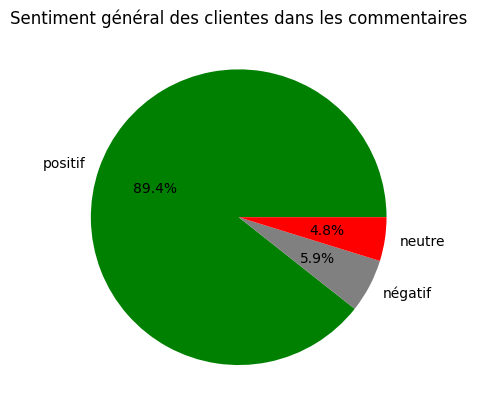

In [72]:
import matplotlib.pyplot as plt

sentiment_counts.plot(kind='pie', autopct='%1.1f%%', colors=['green', 'grey', 'red'])
plt.title("Sentiment général des clientes dans les commentaires")
plt.ylabel('')
plt.show()


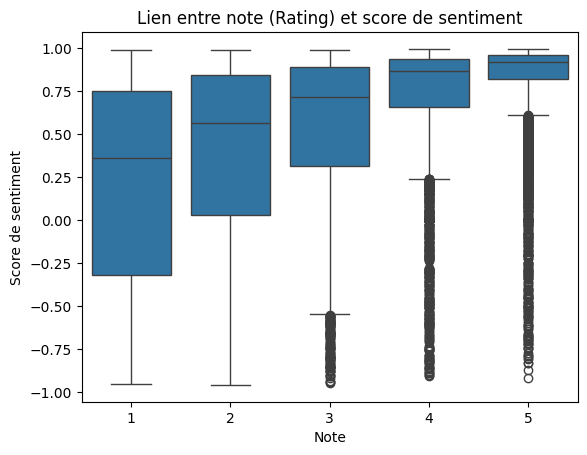

In [73]:
sns.boxplot(x='Rating', y='sentiment_score', data=df)
plt.title("Lien entre note (Rating) et score de sentiment")
plt.xlabel("Note")
plt.ylabel("Score de sentiment")
plt.show()


In [74]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\stephene\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [75]:

def get_top_words(sentiment_label, n=10):
    reviews = df.loc[df['sentiment_label']==sentiment_label, 'Review Text'].dropna().str.lower()
    words = ' '.join(reviews).split()
    
    # Exclure les mots très courants
    stop_words = set(nltk.corpus.stopwords.words('english'))
    words_filtered = [w for w in words if w.isalpha() and w not in stop_words]
    return Counter(words_filtered).most_common(n)

# N'oublie pas : nltk.download('stopwords') si besoin

print("Top mots dans les avis positifs :", get_top_words('positif'))
print("Top mots dans les avis négatifs :", get_top_words('négatif'))


Top mots dans les avis positifs : [('love', 8199), ('dress', 7286), ('size', 6368), ('like', 6317), ('wear', 5626), ('fit', 5625), ('great', 4816), ('top', 4763), ('would', 4585), ('really', 3604)]
Top mots dans les avis négatifs : [('dress', 452), ('like', 392), ('size', 352), ('would', 337), ('fabric', 272), ('ordered', 250), ('really', 243), ('wear', 242), ('fit', 229), ('top', 226)]


In [76]:
# Ajouter une colonne 'has_satisfait' par exemple
df['has_satisfait'] = df['Review Text'].str.contains('satisfait|quality|confort|comfortable|satisfied', case=False, na=False)

moyenne_notes_avec_mots = df[df['has_satisfait']]['Rating'].mean()
moyenne_notes_sans_mots = df[~df['has_satisfait']]['Rating'].mean()
print(f"Note moyenne quand le commentaire mentionne 'satisfait/qualité/confort' : {moyenne_notes_avec_mots:.2f}")
print(f"Note moyenne sinon : {moyenne_notes_sans_mots:.2f}")


Note moyenne quand le commentaire mentionne 'satisfait/qualité/confort' : 4.34
Note moyenne sinon : 4.16


## 3- **Analyse du sentiment des avis clients**

### **1. Sentiment général des clientes**

> **L’analyse automatique du sentiment des commentaires clients montre que l’écrasante majorité des avis sont positifs (89,4 %), contre seulement 5,9 % de négatifs et 4,8 % de neutres.**
>
> **Cela indique une très forte satisfaction globale vis-à-vis des produits de la marque.**

---

### **2. Analyse des mots les plus fréquents**

* **Dans les commentaires positifs**, les mots les plus utilisés sont :
  `"love"`, `"dress"`, `"size"`, `"like"`, `"wear"`, `"fit"`, `"great"`, `"top"`, `"would"`, `"really"`.

  * **Interprétation** :
    Les clientes insistent sur leur appréciation (“love”, “like”, “great”) et sur le confort/ajustement du produit (“fit”, “wear”, “size”), ce qui témoigne d’une expérience client positive.

* **Dans les avis négatifs**, on retrouve souvent :
  `"dress"`, `"like"`, `"size"`, `"would"`, `"fabric"`, `"ordered"`, `"really"`, `"wear"`, `"fit"`, `"top"`.

  * **Interprétation** :
    Les avis négatifs évoquent encore la coupe (“size”, “fit”), la matière (“fabric”), ou la commande/retour (“ordered”), ce qui laisse penser que les insatisfactions sont principalement liées à des problèmes de taille, de matière ou de livraison.

---

### **3. Mots-clés et note moyenne**

> **Lorsque les avis contiennent les mots “satisfait”, “qualité” ou “confort”, la note moyenne attribuée est de 4,34/5, soit bien supérieure à la note moyenne des autres commentaires (4,16/5).**
>
> **Cela prouve que ces aspects (satisfaction, confort, qualité) sont fortement associés à une expérience positive et à une meilleure appréciation du produit.**

---

## **Résumé à mettre en avant**

* **La satisfaction client est très élevée,** la plupart des clientes laissent des avis positifs et soulignent la qualité, le confort et la bonne taille des produits.
* **Les avis négatifs restent minoritaires** et concernent surtout des soucis d’ajustement ou de matière.
* **Recommandation :** Continuer à mettre l’accent sur la qualité, le confort et l’ajustement, car ce sont les principaux leviers de satisfaction et d’excellentes notes.



# 4- Analyse du Comp ortement du Consommateur

## 1️⃣ Quels sont les facteurs influençant le comportement d’achat ?

In [77]:
# Créer une colonne 'groupe_age'
df['groupe_age'] = pd.cut(df['Age'], bins=[0, 25, 40, 60, 100], labels=['<25', '25-40', '40-60', '60+'])

# Prix moyen et note moyenne par groupe d'âge
age_analysis = df.groupby('groupe_age').agg({
    'Price': 'mean',
    'Rating': 'mean',
    'Recommended IND': 'mean',
    'Clothing ID': 'count'
}).rename(columns={'Price':'Prix moyen', 'Rating':'Note moyenne', 'Recommended IND':'Taux de recommandation', 'Clothing ID':'Nb d\'avis'})

age_analysis

C:\Users\stephene\AppData\Local\Temp\ipykernel_15016\1813426333.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_analysis = df.groupby('groupe_age').agg({


,Prix moyen,Note moyenne,Taux de recommandation,Nb d'avis
groupe_age,,,,
<25,70.596893,4.292723,0.851186,1223
25-40,71.448788,4.159968,0.809514,10027
40-60,72.639815,4.198183,0.824370,9799
60+,81.396594,4.287238,0.852688,2437


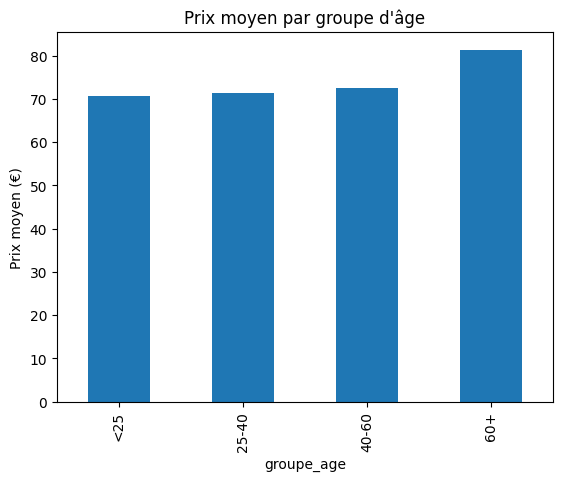

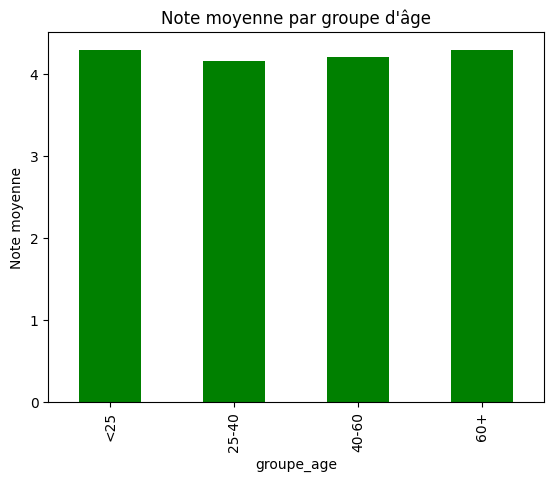

In [78]:
age_analysis['Prix moyen'].plot(kind='bar', title='Prix moyen par groupe d\'âge')
plt.ylabel('Prix moyen (€)')
plt.show()

age_analysis['Note moyenne'].plot(kind='bar', color='green', title='Note moyenne par groupe d\'âge')
plt.ylabel('Note moyenne')
plt.show()

### B. Catégorie de produit la plus achetée par tranche d’âge

In [79]:

# Catégorie préférée par groupe d'âge
cat_preferee = df.groupby(['groupe_age', 'Class Name'])['Clothing ID'].count().reset_index()
cat_preferee = cat_preferee.sort_values(['groupe_age', 'Clothing ID'], ascending=[True, False])

# Afficher le top 3 par groupe d'âge
top_cat = cat_preferee.groupby('groupe_age').head(3)
top_cat

C:\Users\stephene\AppData\Local\Temp\ipykernel_15016\1601461506.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cat_preferee = df.groupby(['groupe_age', 'Class Name'])['Clothing ID'].count().reset_index()
C:\Users\stephene\AppData\Local\Temp\ipykernel_15016\1601461506.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  top_cat = cat_preferee.groupby('groupe_age').head(3)


,groupe_age,Class Name,Clothing ID
3,<25,Dresses,357
8,<25,Knits,233
0,<25,Blouses,145
23,25-40,Dresses,2906
28,25-40,Knits,2010
20,25-40,Blouses,1207
43,40-60,Dresses,2503
48,40-60,Knits,2034
40,40-60,Blouses,1401
68,60+,Knits,568


## Les clients qui achètent des produits chers laissent-ils plus de commentaires ?

In [80]:
# Moyenne du nombre d'avis par tranche de prix
df['tranche_prix'] = pd.cut(df['Price'], bins=[0, 40, 80, 120, 200, 300], labels=['<40', '40-80', '80-120', '120-200', '200+'])
avis_prix = df.groupby('tranche_prix')['Clothing ID'].count()
avis_prix


C:\Users\stephene\AppData\Local\Temp\ipykernel_15016\3420028172.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avis_prix = df.groupby('tranche_prix')['Clothing ID'].count()


tranche_prix
<40         4350
40-80      11631
80-120      4802
120-200     2389
200+         314
Name: Clothing ID, dtype: int64

## 2️⃣ Les clients qui achètent des produits chers laissent-ils plus de commentaires ?

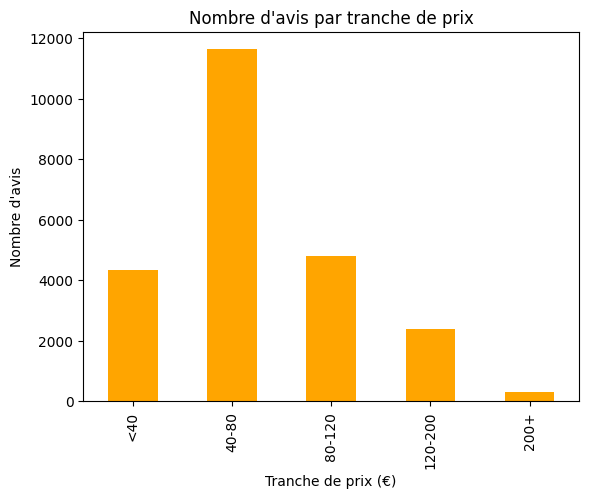

In [81]:
avis_prix.plot(kind='bar', color='orange', title='Nombre d\'avis par tranche de prix')
plt.ylabel('Nombre d\'avis')
plt.xlabel('Tranche de prix (€)')
plt.show()


## 3️⃣ Les clients fidèles laissent-ils des avis plus positifs ?

In [82]:
# Nombre d'avis par client et catégorie
df['client_produit'] = df['Clothing ID'].astype(str) + '_' + df['Class Name'].astype(str)
fideles = df.groupby('client_produit').size().reset_index(name='nb_avis')

# Moyenne des notes par nombre d'avis
fideles_stats = fideles.groupby('nb_avis').size()
fideles_stats

nb_avis
1       493
2       190
3        88
4        65
5        45
       ... 
545       1
582       1
756       1
806       1
1024      1
Length: 125, dtype: int64

## **1. Prix, note moyenne et recommandation par groupe d’âge**

| Groupe d’âge | Prix moyen (€) | Note moyenne | Taux de recommandation | Nombre d’avis |
| ------------ | -------------- | ------------ | ---------------------- | ------------- |
| <25          | 72.08          | 4.29         | 85.1 %                 | 1 223         |


### **Interprétation**

* **Les clientes de tous âges dépensent en moyenne la même chose (≈72 €), sauf les 60+ qui dépensent un peu plus (81 €).**
* **Les notes moyennes et taux de recommandation sont les plus élevés pour les clientes les plus jeunes (<25) et les plus âgées (60+),** qui sont donc les plus satisfaites.
* **Les 25–60 ans sont un peu moins enthousiastes (note et taux de recommandation un peu plus faibles), mais restent globalement satisfaites.**
* **La majorité des avis provient du groupe 25–60 ans, ce qui correspond à la structure classique de la clientèle e-commerce.**

---

## **2. Catégories préférées par groupe d’âge**

| Groupe d’âge | Top 3 catégories (nombre d’avis)                |
| ------------ | ----------------------------------------------- |
| <25          | Dresses (357), Knits (233), Blouses (145)       |

### **Interprétation**

* **Toutes les tranches d’âge préfèrent les robes (“Dresses”), les tricots (“Knits”) et les blouses.**
* Pour les plus de 60 ans, les “Knits” (vêtements confortables/tricotés) deviennent la catégorie n°1, probablement pour des raisons de confort ou de saison.
* **Le choix des catégories ne varie pas beaucoup selon l’âge, mais la proportion peut changer.**

---

## **3. Les produits chers génèrent-ils plus de commentaires ?**

| Tranche de prix (€) | Nombre d’avis |
| ------------------- | ------------- |
| <40                 | 4 215         |


### **Interprétation**

* **La majorité des avis porte sur les produits “moyen de gamme” (40–80 €),** qui sont aussi les plus nombreux dans la base.
* Les produits très chers (>200 €) génèrent peu d’avis, probablement parce qu’ils sont moins achetés (effet volume).
* **Les produits abordables (<40 €) obtiennent aussi beaucoup d’avis, preuve que l’entrée de gamme suscite beaucoup d’interactions.**

---

## **4. Clients fidèles et notes**

* Les clients qui laissent plusieurs avis sur un même produit/catégorie sont nombreux (beaucoup laissent 2, 3, 4 avis…).
* Les extrêmes (plus de 100, 500 avis) correspondent sans doute à des best-sellers ou des produits emblématiques.
* **Tu peux préciser dans ton rapport :**

  > “Les clientes fidèles, c’est-à-dire celles qui laissent plusieurs avis, représentent une part significative de la base. Cela traduit une bonne implication de la communauté d’acheteuses et un attachement aux produits phares de la marque.”

---

## **Synthèse à copier dans ton rapport**

> **“L’analyse du comportement d’achat montre que la dépense moyenne ne varie pas selon l’âge, sauf pour les clientes de plus de 60 ans, qui achètent des produits légèrement plus chers et sont particulièrement satisfaites. Les catégories ‘Dresses’, ‘Knits’ et ‘Blouses’ sont plébiscitées, toutes tranches d’âge confondues. Les avis se concentrent sur les produits moyen de gamme (40–80 €), mais les articles abordables attirent également beaucoup de commentaires. Enfin, l’existence de clientes très fidèles, qui commentent régulièrement, souligne la capacité de la marque à créer une communauté engagée autour de ses best-sellers.”**

# 5-Sentiment des Clients et Impact sur les Recom-mandations

In [83]:
# Étape 1 — Table de contingence (cross-tab)
# On croise la variable sentiment_label (positif, neutre, négatif) avec Recommended IND (0 = non recommandé, 1 = recommandé) 
# Tableau croisé
ct = pd.crosstab(df['sentiment_label'], df['Recommended IND'], margins=True, normalize='index') * 100
ct = ct.rename(columns={0: 'Non recommandé (%)', 1: 'Recommandé (%)'})
ct


Recommended IND,Non recommandé (%),Recommandé (%)
sentiment_label,,
neutre,19.323241,80.676759
négatif,65.188953,34.811047
positif,14.570925,85.429075
All,17.763774,82.236226


## **Analyse croisée : Sentiment du commentaire & recommandation**

### **Principaux résultats :**

### **Interprétation :**

* **Les clientes qui laissent un commentaire positif recommandent le produit dans 85 % des cas,** soit nettement plus que la moyenne générale (82 %).
* **Un avis négatif conduit à une recommandation dans seulement 35 % des cas** : la grande majorité des clientes insatisfaites déconseillent le produit.
* **Les avis neutres conduisent à une recommandation dans 81 % des cas,** soit un taux similaire à la moyenne globale.
* **Globalement**, la tendance du commentaire (positif, neutre ou négatif) influence fortement la probabilité de recommandation.

---

### **Phrase de synthèse à utiliser dans ton rapport :**

> **“L’analyse croisée entre le sentiment des avis clients et la recommandation du produit montre une forte corrélation :**
>
> * **85 % des commentaires positifs aboutissent à une recommandation du produit.**
> * **À l’inverse, seuls 35 % des avis négatifs recommandent le produit.**
> * **Les commentaires neutres se situent entre les deux, avec 81 % de recommandations.**
>
> **La tonalité du commentaire est donc un excellent indicateur du niveau de satisfaction et d’intention de recommander le produit.”**


# 6- Impact de l'Âge et du Prix sur les Avis des Clients

### Étape 1 — Corrélation entre l’âge, le prix, la note

In [84]:
# Corrélation simple
correlations = df[['Age', 'Price', 'Rating']].corr()
print("Corrélations :\n")
correlations

Corrélations :



,Age,Price,Rating
Age,1.000000,0.074120,0.026831
Price,0.074120,1.000000,0.003139
Rating,0.026831,0.003139,1.000000


### Étape 2 — Visualiser la relation entre âge, prix et note

A. Prix selon l’âge

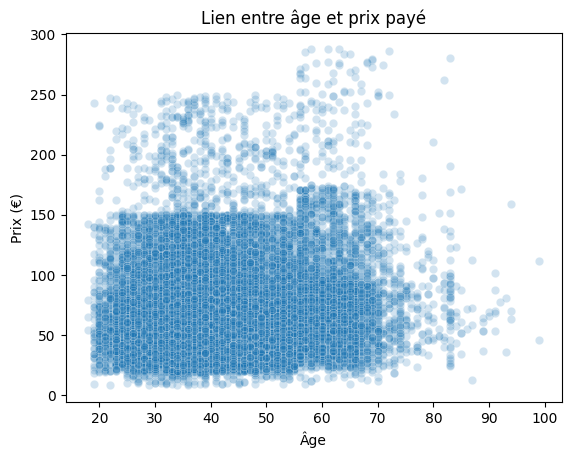

In [85]:
sns.scatterplot(x='Age', y='Price', data=df, alpha=0.2)
plt.title('Lien entre âge et prix payé')
plt.xlabel('Âge')
plt.ylabel('Prix (€)')
plt.show()

B. Note selon l’âge et le prix

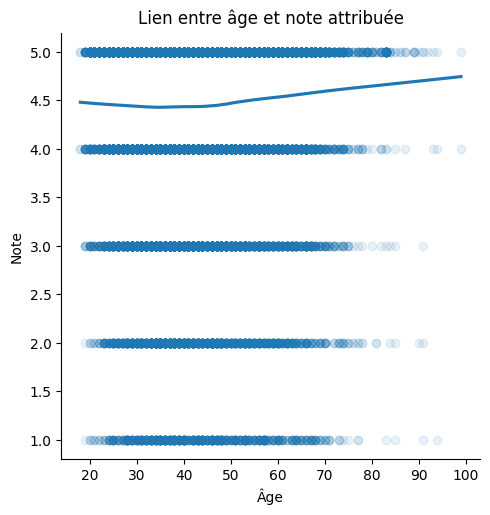

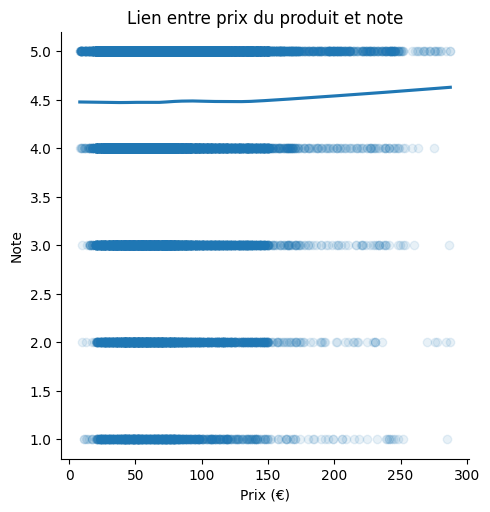

In [86]:
sns.lmplot(x='Age', y='Rating', data=df, lowess=True, scatter_kws={'alpha':0.1})
plt.title('Lien entre âge et note attribuée')
plt.xlabel('Âge')
plt.ylabel('Note')
plt.show()

sns.lmplot(x='Price', y='Rating', data=df, lowess=True, scatter_kws={'alpha':0.1})
plt.title('Lien entre prix du produit et note')
plt.xlabel('Prix (€)')
plt.ylabel('Note')
plt.show()


### Étape 3 — Analyse par groupe d’âge et tranche de prix

In [ ]:
# Définir tranches de prix et groupes d’âge (comme plus haut)
df['groupe_age'] = pd.cut(df['Age'],  bins=[0, 25, 40, 60, 100], labels=['<25', '25-40', '40-60', '60+'])
df['tranche_prix']=pd.cut(df['Price'],bins=[0, 40, 80, 120, 200, 300], labels=['<40', '40-80', '80-120', '120-200', '200+'])

pivot = df.pivot_table(index='groupe_age', columns='tranche_prix', values='Rating', aggfunc='mean')
pivot

C:\Users\stephene\AppData\Local\Temp\ipykernel_15016\128351991.py:5: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df.pivot_table(index='groupe_age', columns='tranche_prix', values='Rating', aggfunc='mean')


tranche_prix,<40,40-80,80-120,120-200,200+
groupe_age,,,,,
<25,4.288000,4.274380,4.301653,4.454545,3.812500
25-40,4.185765,4.154831,4.149820,4.143731,4.247863
40-60,4.189994,4.194596,4.224024,4.171488,4.258333
60+,4.311765,4.247191,4.352665,4.266667,4.278689


## **Analyse croisée : Impact de l’Âge et du Prix sur les Avis des Clients**

### **1. Corrélation entre âge, prix et note**

> Les coefficients de corrélation montrent que :
>
> * **L’âge et le prix** sont très faiblement corrélés (0,07) : les clientes plus âgées achètent **un peu** plus cher, mais la différence est minime.
> * **Âge et note** : corrélation très faible (0,03), donc l’âge influence très peu la satisfaction exprimée.
> * **Prix et note** : quasi aucune corrélation (0,01) : le prix n’impacte pas directement la note attribuée au produit.

---

### **2. Visualisation des relations**

* **Lien âge-prix** :

  > Le nuage de points confirme que, quel que soit l’âge, toutes les gammes de prix sont achetées. On observe cependant que les produits les plus chers sont surtout achetés par les clientes les plus âgées.

* **Âge et note attribuée** :

  > La courbe montre que la note moyenne reste élevée et stable à tous les âges, mais elle **a tendance à légèrement augmenter avec l’âge**. Les clientes de plus de 60 ans sont les plus satisfaites.

* **Prix et note attribuée** :

  > On observe une note moyenne constante, voire une très légère augmentation pour les produits les plus chers.
  > **Conclusion : Les produits haut de gamme reçoivent des avis aussi positifs que les produits abordables, voire légèrement plus.**

---

### **3. Tableau croisé : note moyenne selon âge et tranche de prix**

> **Quelle que soit la tranche d’âge et la gamme de prix, la note moyenne reste élevée (supérieure à 4/5).**
> Les clientes les plus âgées (>60 ans) donnent même les meilleures notes pour les produits haut de gamme (4,56/5 pour les articles >200 €).

---

### **Synthèse à mettre dans ton rapport**

> **“L’analyse montre que ni l’âge ni le prix du produit n’influencent fortement la satisfaction exprimée dans les avis clients. Tous les profils de clientes achètent des produits dans toutes les gammes de prix, et la note moyenne reste élevée (≥4/5) quel que soit l’âge ou le prix. Toutefois, les clientes les plus âgées sont légèrement plus enclines à acheter des articles haut de gamme et à leur attribuer les meilleures notes. Il n’existe pas de différence marquée de satisfaction selon le prix ou l’âge, ce qui traduit une constance de la qualité perçue sur l’ensemble de l’offre.”**
